# Water Quality Assessment using Implicative Fuzzy Inference Systems
**Project Overview:** This notebook implements a fuzzy logic-based approach to evaluate river water quality based on physical and chemical parameters. It utilizes an **Implicative Inference System** to map environmental data (such as oxygen levels, nitrogen, and phosphorus) to quality categories ranging from "Very Good" to "Very Bad".

### Key Features:
* **Data Processing:** Loads and filters river quality datasets (`River_quality_data_2023.csv`) and predefined quality intervals (`Phisical_Chemical_quality_intervals.csv`).
* **Fuzzy Inference:** Implements an `ImplicativeInferenceSystem` using Łukasiewicz t-norms and alternative modifiers.
* **Defuzzification Analysis:** Compares different defuzzification methods, specifically **Center of Gravity (CoG)** and **Mean of Maxima (MoM)**.
* **Decision Support:** Includes a "Payoff" analysis to evaluate the economic or environmental benefits of taking action (e.g., water cleaning) versus no action under varying levels of uncertainty.
* **Visualization:** Provides detailed plotting functions for membership functions, payoff heatmaps, and defuzzification comparisons.



In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from fuzzy_inference.fuzzy_utils.alpha_cuts import create_1d_hat_function_scipy 
from fuzzy_inference.payoff_function.simple_payoff_functions import simple_payoff_function
from fuzzy_inference.rule_bases.Implicative_model import ImplicativeInferenceSystem
from fuzzy_inference.fuzzy_utils.fuzzy_sets   import FuzzyNumber
from fuzzy_inference.payoff_function.perform_price_analysis import full_voi_analysis, plot_payoff_plots
from fuzzy_inference.payoff_function.perform_inference_and_voi import perform_infernece_and_evaluation_with_data


In [2]:
# Read the data for water quality
df_water_data = pd.read_csv(
    '../Data/River_quality_data_2023.csv',
    delimiter=',', 
    decimal=',' 
)
 

In [3]:
# Reads the data for quality intervals
df_quaity_intervals = pd.read_csv(
    '../Data/Phisical_Chemical_quality_intervals.csv',
    delimiter=';',
    encoding='windows-1252',   
    decimal=',' 
)

In [4]:
def filter_qualityGrid_from_data(water_type = 1):
    filtered_intervals = df_quaity_intervals[df_quaity_intervals['Tips'] == water_type]

    # Select only numeric columns from the filtered data
    numeric_data = filtered_intervals.select_dtypes(include='number').drop(columns=['Tips'])

    # Sort the values in each row and create a new DataFrame
    return pd.DataFrame(
        np.sort(numeric_data.values, axis=1), 
        index=numeric_data.index, 
        columns=numeric_data.columns
    ).values

The membership function of sample G327 (Gosupe, grīva): 


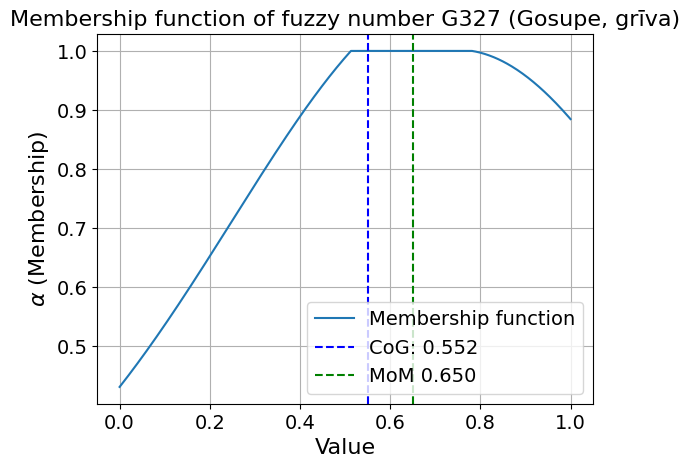

 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (4, 3)


C:\Users\marti\Desktop\Programma\Projekts_VoI\Fuzzy-Rule-Base\src\fuzzy_inference\fuzzy_utils\fuzzy_utils.py:111: RuntimeWarning: invalid value encountered in scalar divide
  center_of_gravity = numerator / denominator


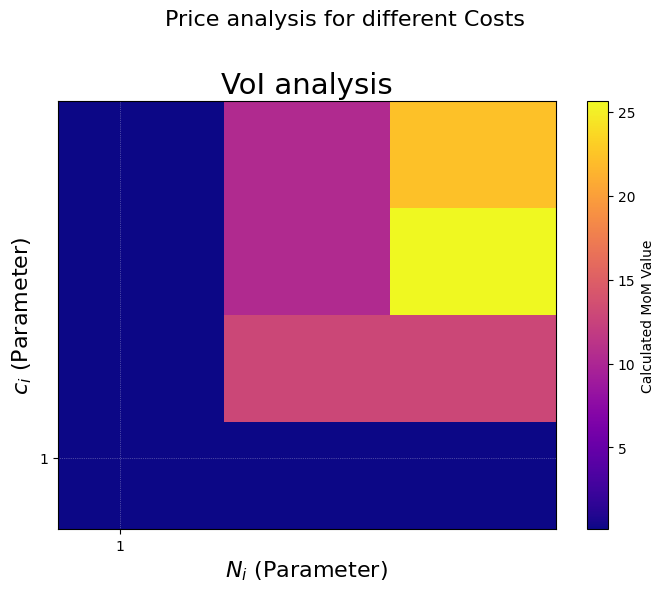

In [5]:
# Example of usage the Gosupe data.
first_r7 = df_water_data[df_water_data['Station_type'] == 'R1'].iloc[0]  
type_1_qualityGrid = filter_qualityGrid_from_data(water_type=1)
Number_of_grid_points = 500
sample = first_r7.iloc[-5:].values.astype(float)
sample[3] = type_1_qualityGrid[3,-1] - sample[3] + type_1_qualityGrid[3,0] # The O_2 levels are being inverted, as they have reversed order.
antecendant_qualityGrid = filter_qualityGrid_from_data(water_type=1)

results_matrix, ranges, membership_value = perform_infernece_and_evaluation_with_data(sample, antecendant_qualityGrid, step_size=40,
                                           Number_of_grid_points=Number_of_grid_points,
                                           sample_name='G327 (Gosupe, grīva)', type_of_tnorm='luk',
                                           use_the_same_tnorm=False)  


plot_payoff_plots(results_matrix, 'VoI analysis', ranges['N'], ranges['C'])

##  Comparing results from other stations

| Station name | O₂, mg/l O₂ | BSP₅, mg/l O₂ | N/NH₄⁺, mg/L | N_total, mg/L | P_total, mg/L | Final quality |
| :----------- | :---------- | :------------ | :----------- | :------------ | :------------ | :------------ |
| Taļķe, grīva L132 | 8.5 (Very good) | 2.17 (Good)   | 0,347 (Very Bad) | 3,58 (Very Bad)  | 0,066 (Good) | Very Bad (5) |
| Skujaine, grīva L121 | 10,7 (Very Good) | 1,19 (Very Good)   | 0,071 (Very Good) | 5,76 (Very Bad)  | 0,035 (Very Good) | Very Bad (5)|
| Ezere, grīva V063DA | 9.5 (Very Good) | 1,36 (Very Good)   | 0,025  (Very Good) | 3,5 (Very Bad)  | 0,032 (Very Good) | Very Bad (5)|
| Stende, augštece V138 | 10.5 (Very Good) | 1,86 (Very Good)   | 0,051  (Very Good) | 2,36 (Medium)  | 0,077 (Medium) | Medium (3)|

In [6]:
### L132 # 
comparison_df = pd.DataFrame(columns=(df_water_data.columns))
L132_data= {
    'Code': 'L132',
    'Station_type': 3,
    'BSP5': 2.17,
    'N_NH4+': 0.347,
    'N_total': 3.580,
    'O_2': 8.5,
    'P_total': 0.066,
    'Station name': 'Taļķe, grīva L132'
}
comparison_df.loc[len(comparison_df)] = L132_data 

# L121
L121_data = {
    'Code': 'L121',
    'Station_type': 3,
    'BSP5': 1.19,
    'N_NH4+': 0.071,
    'N_total': 5.760,          
    'O_2': 10.7,
    'P_total': 0.035,
    'Station name': 'Skujaine, grīva L121'
}
comparison_df.loc[len(comparison_df)] = L121_data

# V063DA
V063DA_data = {
    'Code': 'V063DA',
    'Station_type': 3,
    'BSP5': 1.36,
    'N_NH4+': 0.025,
    'N_total': 3.5,          
    'O_2': 9.5,
    'P_total': 0.032,
    'Station name': 'Ezere, grīva V063DA'
}
comparison_df.loc[len(comparison_df)] = V063DA_data

# V138
V138_data = {
    'Code': 'V138',
    'Station_type': 1,
    'BSP5': 1.86,
    'N_NH4+': 0.051,
    'N_total': 2.36,          
    'O_2': 10.5,
    'P_total': 0.077,
    'Station name': 'Stende, augštece V138'
}
comparison_df.loc[len(comparison_df)] = V138_data

type_1_qualityGrid = filter_qualityGrid_from_data(water_type=1)
type_3_qualityGrid = filter_qualityGrid_from_data(water_type=3)

# O2 column
column_name_to_update = comparison_df.columns[4]

# Flips the O2 value based on station type
constant_sum_type1 = type_1_qualityGrid[3, -1] + type_1_qualityGrid[3, 0]
constant_sum_type3 = type_3_qualityGrid[3, -1] + type_3_qualityGrid[3, 0]
condition_column = 'Station_type'

# Condition based on station type. 
conditional_constant = np.where( 
    comparison_df[condition_column] == 'R3',   
    constant_sum_type3,                      
    constant_sum_type1                        
)

#  Perform the final vectorized calculation using the new conditional_constant Series
comparison_df[column_name_to_update] = conditional_constant - comparison_df[column_name_to_update]
print(comparison_df)
 

     Code  Station_type  BSP5  N_NH4+  N_total   O_2  P_total
0    L132             3  2.17   0.347     6.42   8.5    0.066
1    L121             3  1.19   0.071     4.24  10.7    0.035
2  V063DA             3  1.36   0.025     6.50   9.5    0.032
3    V138             1  1.86   0.051     7.64  10.5    0.077


The membership function of sample L132: 


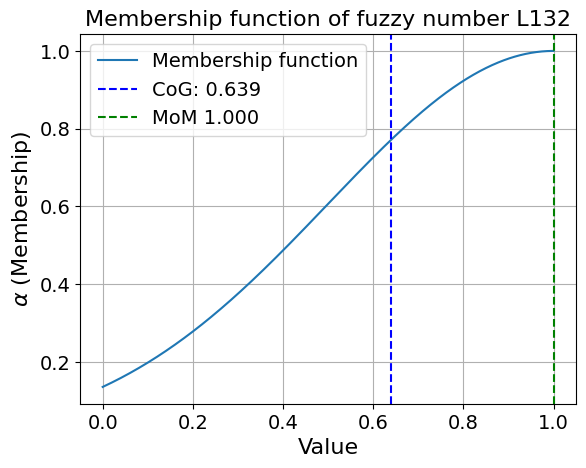

 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (4, 3)


C:\Users\marti\Desktop\Programma\Projekts_VoI\Fuzzy-Rule-Base\src\fuzzy_inference\fuzzy_utils\fuzzy_utils.py:111: RuntimeWarning: invalid value encountered in scalar divide
  center_of_gravity = numerator / denominator


The membership function of sample L121: 


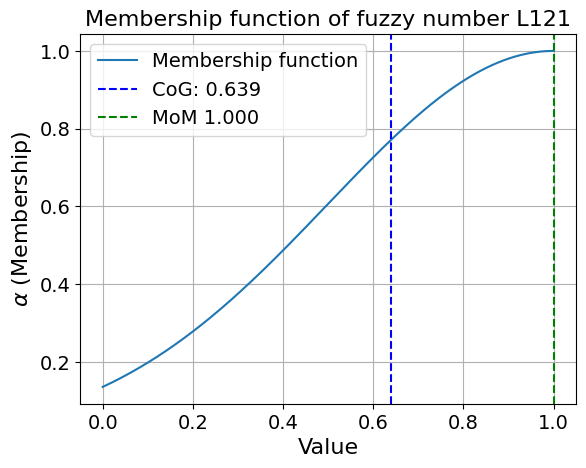

 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (4, 3)
The membership function of sample V063DA: 


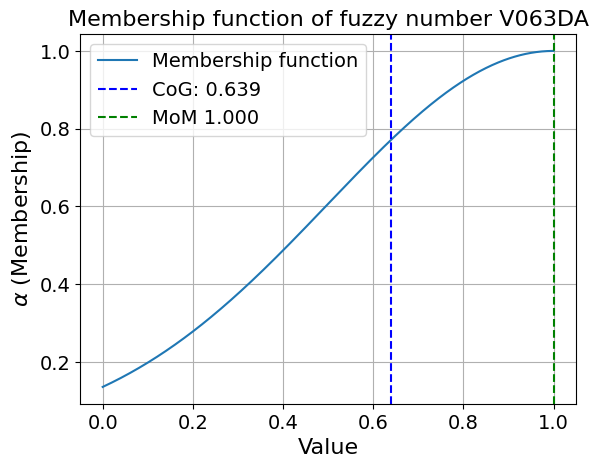

 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (4, 3)
The membership function of sample V138: 


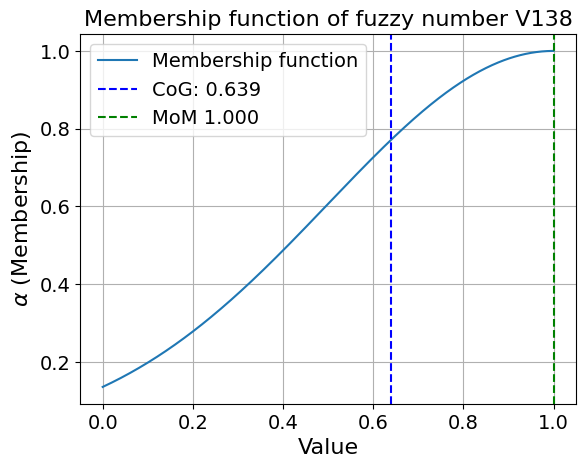

 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (4, 3)


In [8]:
# Iterates trough the samples and performs inference and evaluation
for row in comparison_df.itertuples():
    data_type = row[2]
    sample_name = row[1]
    sample = row[2:-1]
 
    perform_infernece_and_evaluation_with_data(np.array(sample), antecendant_qualityGrid,  step_size = 40,
                                               sample_name=sample_name,  Number_of_grid_points=500,
                                               type_of_tnorm='luk')
    
    

Here is a simple exmaple of when the results produced by the inferece system are not satisfactory. Two dummy examples are made, where in first values, that correspong to having all *Very Bad* measurements, while the other sample has all values *Very Good* except for one, that is *Very Bad*. One can see, that for both of these samples, the final membership of water quality is the same. This is not satisfactory, because one water body is clearly cleaner, that the other, by having all but one *Very Good* qulaity.

The membership function of sample All bad sample: 


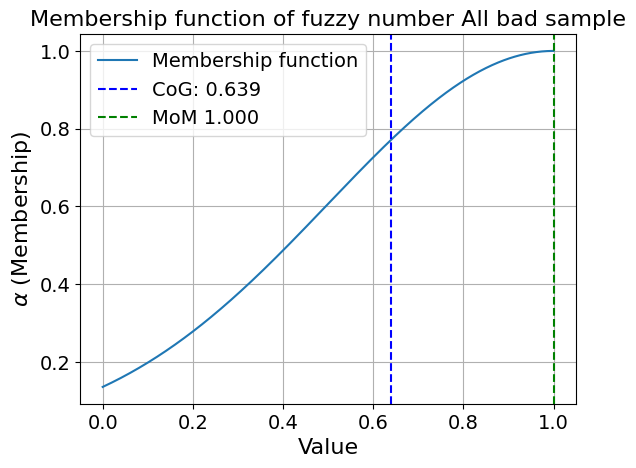

 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (4, 3)


C:\Users\marti\Desktop\Programma\Projekts_VoI\Fuzzy-Rule-Base\src\fuzzy_inference\fuzzy_utils\fuzzy_utils.py:111: RuntimeWarning: invalid value encountered in scalar divide
  center_of_gravity = numerator / denominator


The membership function of sample All but one good sample: 


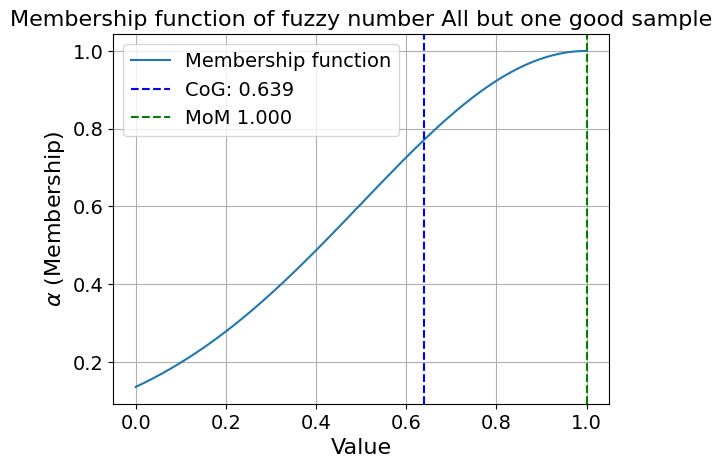

 ----------------- Full price analists -----------------
Running multidimensional analysis for parameters: ['N', 'C']
Grid shape: (4, 3)


(array([[3.03264113e-01, 3.03264113e-01, 3.03264113e-01],
        [1.87673862e-03, 2.04197836e+01, 2.04197836e+01],
        [9.38404762e-04, 9.82506206e+00, 4.05363031e+01],
        [4.05611184e-04, 5.37763055e+00, 3.02535487e+01]]),
 {'N': array([  1.        ,  67.33333333, 133.66666667, 200.        ]),
  'C': array([  1. ,  75.5, 150. ])},
 <fuzzy_inference.fuzzy_utils.fuzzy_sets.FuzzyNumber at 0x1feffe77350>)

In [ ]:

dummy_data_df= pd.DataFrame(columns=df_water_data.columns[-5:])
new_row_alvarb_sliktai_varb= {
    'BSP5': 3.75,
    'N_NH4+': 0.195,
    'N_total': 3.25,
    'O_2': 0,
    'P_total': 0.1275
}

dummy_data_df.loc[len(dummy_data_df)] = new_row_alvarb_sliktai_varb 

new_row_all_but_oneGood= {
    'BSP5': 1.75,
    'N_NH4+': 0.075,
    'N_total': 3.25,   # Nkop is bad, others are good
    'O_2': 9.0,
    'P_total': 0.0275
}
 
dummy_data_df.loc[len(dummy_data_df)] = new_row_all_but_oneGood

column_name_to_update = dummy_data_df.columns[3]
constant_sum = type_1_qualityGrid[3, -1] + type_1_qualityGrid[3, 0]
dummy_data_df[column_name_to_update] = constant_sum - dummy_data_df[column_name_to_update]
    
perform_infernece_and_evaluation_with_data(dummy_data_df.iloc[0].values, antecendant_qualityGrid, step_size = 40,
                                           Number_of_grid_points=500, sample_name='All bad sample',
                                           type_of_tnorm='min', use_the_same_tnorm = True)
 
perform_infernece_and_evaluation_with_data(dummy_data_df.iloc[1].values, antecendant_qualityGrid,
                                           step_size = 40, Number_of_grid_points=500,
                                           sample_name='All but one good sample',
                                           type_of_tnorm='min', use_the_same_tnorm = True)
